In [ ]:
import os
import librosa
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf

## Importing Audio

In [ ]:
random_file_name = "Data/genres_original/blues/blues.00000.wav"

## Visualising Audio

In [ ]:
y, sr = librosa.load(random_file_name, sr = 44100)
plt.figure(figsize=(14, 5))
librosa.display.waveshow(y, sr = sr)

## Play sound

In [ ]:
from IPython.display import Audio
Audio(data=y, rate=sr)

## Doing visualization on chunks of audio

In [ ]:
audio_path = "Data/genres_original/blues/blues.00000.wav"
y, sr = librosa.load(random_file_name, sr=None) #sr = None to keep orgiinal sampking rate


#define the duration of each chunk and overlap
chunk_duration = 4 # 4sec
overlap_duration = 2 # overlap because to mainatin prevoius inforamtion

# COnvert duration to sample
chunk_samples = chunk_duration * sr
overlap_samples = overlap_duration * sr

# Calucalte no. of chunks
num_chunks = int(np.ceil(
    (len(y) - chunk_samples) / (chunk_samples-overlap_samples)
)) + 1

# Iterate over each chunks
for i in range(num_chunks):
    #calculate start & end indices of chunk
    start = i* (chunk_samples-overlap_samples)
    end = start + chunk_samples

    #extract chunk audio
    chunk = y[start:end]
    plt.figure(figsize=(4,2))
    librosa.display.waveshow(chunk, sr = sr)
    plt.show()

In [ ]:
y.shape

In [ ]:
# MELSPECTEROGRAM

In [ ]:
#plotting Melspectrogram of entire Audio
def plot_melspectrogram(y, sr):
    #Compute spectrogram
    spectrogram = librosa.feature.melspectrogram(y=y, sr = sr)
    #Convert to decibels(log, scale)
    spectrogram_db = librosa.power_to_db( spectrogram, ref=np.max)
    #visualize the spectrgoram
    plt.figure(figsize=(10, 4))
    librosa.display.specshow(spectrogram_db, sr=sr, x_axis='time', y_axis='mel')
    plt.colorbar(format = '%2.0f dB')
    plt.title("Spectrogram")
    plt.tight_layout()
    plt.show()

In [ ]:
y, sr = librosa.load(random_file_name, sr = 44100)
plot_melspectrogram(y, sr)

In [ ]:
def plot_melspectrogram_chunks(y, sr):
    #define the duration of each chunk and overlap
    chunk_duration = 4
    overlap_duration = 2

    chunk_samples = chunk_duration * sr
    overlap_samples = overlap_duration * sr

    num_chunks = int(np.ceil(
        (len(y) - chunk_samples) / (chunk_samples-overlap_samples)
    )) + 1

    # Iterate over each chunks
    for i in range(num_chunks):
        #calculate start & end indices of chunk
        start = i* (chunk_samples-overlap_samples)
        end = start + chunk_samples

        #extract chunk audio
        chunk = y[start:end]

        #Melsprectrogram
        spectrogram = librosa.feature.melspectrogram(y = chunk, sr = sr)
        print(spectrogram.shape)
        spectrogram_db = librosa.power_to_db( spectrogram, ref=np.max)

        # visualize the spectrogram
        plt.figure(figsize=(10, 4))
        librosa.display.specshow(spectrogram_db, sr=sr, x_axis='time', y_axis='mel')
        plt.colorbar(format = '%2.0f dB')
        plt.title("Spectrogram")
        plt.tight_layout()
        plt.show()


In [ ]:
y, sr = librosa.load(random_file_name, sr = 44100)
plot_melspectrogram_chunks(y, sr)

In [ ]:
128*245

# Data Preprocessing

In [ ]:
## folder structur
data_dir = "./Data/genres_original/"
classes = ['blues', 'classical','country','disco','hiphop','jazz','metal','pop','reggae','rock']


In [ ]:
from tensorflow.image import resize

In [ ]:
def load_and_preprocess_data(data_dir, classes, target_shape=(210,210)):

    # list to store spectrogram data
    data = []

    # list to store labels
    labels = []

    # loop through each genre folder
    for i_class, class_name in enumerate(classes):

        class_dir = os.path.join(data_dir, class_name)
        print("Processing--", class_name)

        # loop through audio files in the folder
        for filename in os.listdir(class_dir):

            if filename.endswith('.wav'):

                file_path = os.path.join(class_dir, filename)

                # try loading the audio file (skip corrupted ones)
                try:
                    audio_data, sample_rate = librosa.load(file_path, sr=None)
                except:
                    print("Skipping corrupted file:", file_path)
                    continue

                # chunk parameters
                chunk_duration = 4      # seconds
                overlap_duration = 2    # seconds

                # convert seconds to samples
                chunk_samples = chunk_duration * sample_rate
                overlap_samples = overlap_duration * sample_rate

                # calculate number of chunks
                num_chunks = int(np.ceil(
                    (len(audio_data) - chunk_samples) /
                    (chunk_samples - overlap_samples)
                )) + 1

                # process each chunk
                for i in range(num_chunks):

                    start = i * (chunk_samples - overlap_samples)
                    end = start + chunk_samples

                    chunk = audio_data[start:end]

                    # create mel spectrogram
                    mel_spectrogram = librosa.feature.melspectrogram(
                        y=chunk, sr=sample_rate
                    )

                    # resize spectrogram for CNN input
                    mel_spectrogram = resize(
                        np.expand_dims(mel_spectrogram, axis=-1),
                        target_shape
                    )

                    # store data and label
                    data.append(mel_spectrogram)
                    labels.append(i_class)

    # convert lists to numpy arrays
    return np.array(data), np.array(labels)


In [ ]:
data, labels = load_and_preprocess_data(data_dir, classes)

Processing-- blues
Processing-- classical
Processing-- country
Processing-- disco
Processing-- hiphop
Processing-- jazz


C:\Users\adars\AppData\Local\Temp\ipykernel_6148\2204305733.py:24: UserWarning: PySoundFile failed. Trying audioread instead.
  audio_data, sample_rate = librosa.load(file_path, sr=None)
E:\Softwares\Anaconda\envs\tensorflow\lib\site-packages\librosa\core\audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


Skipping corrupted file: ./Data/genres_original/jazz\jazz.00054.wav
Processing-- metal
Processing-- pop
Processing-- reggae
Processing-- rock


In [ ]:
data.shape

(14975, 210, 210, 1)

In [ ]:
labels.shape

(14975,)

In [ ]:
## One Hot Encoding

In [ ]:
from tensorflow.keras.utils import to_categorical

In [ ]:
labels = to_categorical( labels, num_classes= len(classes)) # converting label to ohe
labels

array([[1., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 0., 1.]], dtype=float32)

In [ ]:
labels.shape

(14975, 10)

In [ ]:
np.save("data.npy", data)
np.save("labels.npy", labels)

In [ ]:
data = np.load("data.npy")
labels = np.load("labels.npy")

# Splitting of Dataset into Training and Test set

In [ ]:
X = data.astype("float32")
y = labels.astype("float32")

In [ ]:
!pip install scikit-learn

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Building Model

In [ ]:
model = tf.keras.models.Sequential()

In [ ]:
X_train[0].shape

(150, 150, 1)

In [ ]:
from tensorflow.keras.layers import Input,Conv2D, MaxPool2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam

In [ ]:
model.add(Input(shape=X_train[0].shape))

model.add(Conv2D(
    filters=32,
    kernel_size=3,
    padding='same',
    activation='relu'
))

model.add(Conv2D(
    filters=32,
    kernel_size=3,
    activation='relu'
))

model.add(MaxPool2D(
    pool_size=2,
    strides=2
))

In [ ]:
model.add(Conv2D(
    filters=64,
    kernel_size=3,
    padding='same',
    activation='relu'
))

model.add(Conv2D(
    filters=64,
    kernel_size=3,
    activation='relu'
))

model.add(MaxPool2D(
    pool_size=2,
    strides=2
))

In [ ]:
model.add(Conv2D(
    filters=128,
    kernel_size=3,
    padding='same',
    activation='relu'
))

model.add(Conv2D(
    filters=128,
    kernel_size=3,
    activation='relu'
))

model.add(MaxPool2D(
    pool_size=2,
    strides=2
))

In [ ]:
model.add(Conv2D(
    filters=256,
    kernel_size=3,
    padding='same',
    activation='relu'
))

model.add(Conv2D(
    filters=256,
    kernel_size=3,
    activation='relu'
))

model.add(MaxPool2D(
    pool_size=2,
    strides=2
))

In [ ]:
model.add(Dropout(0.3))

model.add(Flatten())

model.add(Dense(256, activation='relu'))

model.add(Dropout(0.4))


In [ ]:
model.add(Dense(10, activation='softmax'))

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 150, 150, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 148, 148, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 74, 74, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 72, 72, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 36, 36, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 34, 34, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 17, 17, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 15, 15, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 7, 7, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 7, 7, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     3,211,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,385,770 (16.73 MB)

 Trainable params: 4,385,770 (16.73 MB)

 Non-trainable params: 0 (0.00 B)

## Compile

In [ ]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
training_history = model.fit(
    X_train,
    y_train,
    epochs=25,
    batch_size=32,
    validation_data=(X_test, y_test)
)

Epoch 1/25
375/375 ━━━━━━━━━━━━━━━━━━━━ 53s 101ms/step - accuracy: 0.3615 - loss: 1.7553 - val_accuracy: 0.5159 - val_loss: 1.3947
Epoch 2/25
375/375 ━━━━━━━━━━━━━━━━━━━━ 25s 66ms/step - accuracy: 0.5598 - loss: 1.2745 - val_accuracy: 0.6391 - val_loss: 1.0429
Epoch 3/25
375/375 ━━━━━━━━━━━━━━━━━━━━ 25s 67ms/step - accuracy: 0.6549 - loss: 0.9921 - val_accuracy: 0.7269 - val_loss: 0.8053
Epoch 4/25
375/375 ━━━━━━━━━━━━━━━━━━━━ 26s 69ms/step - accuracy: 0.7381 - loss: 0.7746 - val_accuracy: 0.7289 - val_loss: 0.7772
Epoch 5/25
375/375 ━━━━━━━━━━━━━━━━━━━━ 26s 68ms/step - accuracy: 0.7786 - loss: 0.6561 - val_accuracy: 0.8230 - val_loss: 0.5498
Epoch 6/25
375/375 ━━━━━━━━━━━━━━━━━━━━ 25s 68ms/step - accuracy: 0.8157 - loss: 0.5495 - val_accuracy: 0.7963 - val_loss: 0.6302
Epoch 7/25
375/375 ━━━━━━━━━━━━━━━━━━━━ 26s 68ms/step - accuracy: 0.8407 - loss: 0.4721 - val_accuracy: 0.8347 - val_loss: 0.4968
Epoch 8/25
375/375 ━━━━━━━━━━━━━━━━━━━━ 26s 68ms/step - accuracy: 0.8690 - loss: 0.3854 -

In [ ]:
model.save("Trained_model.h5")

In [ ]:

training_history.history

{'accuracy': [0.3615191876888275,
  0.559849739074707,
  0.6549248695373535,
  0.7380634546279907,
  0.7786310315132141,
  0.8156928420066833,
  0.8406510949134827,
  0.8690317273139954,
  0.8789649605751038,
  0.8928213715553284,
  0.9005008339881897,
  0.9090985059738159,
  0.9252086877822876,
  0.9274624586105347,
  0.9222871661186218,
  0.9291318655014038,
  0.9454089999198914,
  0.9403172135353088,
  0.936227023601532,
  0.9453255534172058,
  0.9480801224708557,
  0.9564273953437805,
  0.9470784664154053,
  0.9514190554618835,
  0.9518364071846008],
 'loss': [1.7552858591079712,
  1.2745088338851929,
  0.9920960664749146,
  0.7745674848556519,
  0.6560951471328735,
  0.5494874119758606,
  0.4721123278141022,
  0.3854094445705414,
  0.3516992926597595,
  0.3175996243953705,
  0.30208921432495117,
  0.2686101496219635,
  0.22176842391490936,
  0.2141566127538681,
  0.23665213584899902,
  0.20820778608322144,
  0.17248490452766418,
  0.17865964770317078,
  0.19359010457992554,
  0.16

In [ ]:
#Recording History in json
import json
with open('training_hist.json','w') as f:
  json.dump(training_history.history,f)

In [ ]:

X_train

array([[[[3.2394952e+02],
         [1.3065462e+02],
         [6.7034540e+00],
         ...,
         [4.3478956e+00],
         [3.3688255e+01],
         [7.3319199e+01]],

        [[6.4282861e+02],
         [3.4481317e+02],
         [2.4032494e+01],
         ...,
         [5.4154781e+01],
         [1.8837805e+02],
         [2.7204626e+02]],

        [[4.7228046e+02],
         [2.4064510e+02],
         [2.2244192e+01],
         ...,
         [1.0659833e+02],
         [3.5626904e+02],
         [2.6705249e+02]],

        ...,

        [[2.5943064e-03],
         [5.4452824e-04],
         [3.3627577e-05],
         ...,
         [2.4564300e-05],
         [3.0641881e-05],
         [6.9904629e-05]],

        [[2.5715523e-03],
         [5.2518921e-04],
         [2.9510522e-06],
         ...,
         [2.1084190e-06],
         [6.1495894e-06],
         [5.3449046e-05]],

        [[2.5453656e-03],
         [5.1769981e-04],
         [7.9050622e-08],
         ...,
         [7.0884823e-08],
        

In [ ]:
#Reloading model variable
model = tf.keras.models.load_model("Trained_model.h5")
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 150, 150, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 148, 148, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 74, 74, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 72, 72, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 36, 36, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 34, 34, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 17, 17, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 15, 15, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 7, 7, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 7, 7, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     3,211,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,385,772 (16.73 MB)

 Trainable params: 4,385,770 (16.73 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

In [ ]:
#Reloading Training history
import json
with open("training_hist.json",'r') as json_file:
    training_history_data = json.load(json_file)

In [ ]:
training_history_data.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

## Model Evaluation - I

In [ ]:
#Model evaluation on Training set
train_loss,train_accuracy = model.evaluate(X_train,y_train)

375/375 ━━━━━━━━━━━━━━━━━━━━ 10s 23ms/step - accuracy: 0.9867 - loss: 0.0459


In [ ]:

train_loss,train_accuracy

(0.04593352600932121, 0.9867278933525085)

In [ ]:
#Model evaluation on Validation set
val_loss,val_accuracy = model.evaluate(X_test,y_test)

94/94 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - accuracy: 0.8988 - loss: 0.3788


In [ ]:
val_loss,val_accuracy


(0.3787902593612671, 0.8988313674926758)

In [ ]:
training_history_data['val_loss']

[1.394654631614685,
 1.0428786277770996,
 0.8052994608879089,
 0.7772147059440613,
 0.5497520565986633,
 0.630181610584259,
 0.4968074560165405,
 0.45395922660827637,
 0.4866407811641693,
 0.4051240086555481,
 0.582202136516571,
 0.46517592668533325,
 0.392375648021698,
 0.44192931056022644,
 0.5681226253509521,
 0.4264276623725891,
 0.3475407361984253,
 0.4185001254081726,
 0.4322757124900818,
 0.46764838695526123,
 0.3826737701892853,
 0.43748584389686584,
 0.38737520575523376,
 0.4411191940307617,
 0.3787902593612671]

## Accuracy and Loss Visualization

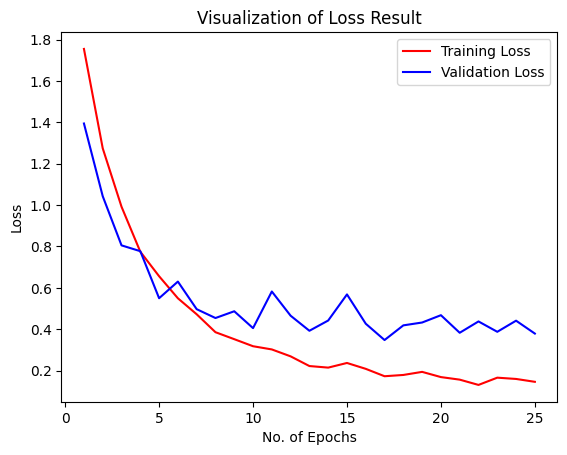

In [ ]:
#Visualization of Loss
epochs = [i for i in range(1, len(training_history_data['loss']) + 1)]
plt.plot(epochs,training_history_data['loss'],label="Training Loss",color='red')
plt.plot(epochs,training_history_data['val_loss'],label="Validation Loss",color='blue')
plt.xlabel("No. of Epochs")
plt.ylabel("Loss")
plt.title("Visualization of Loss Result")
plt.legend()
plt.show()

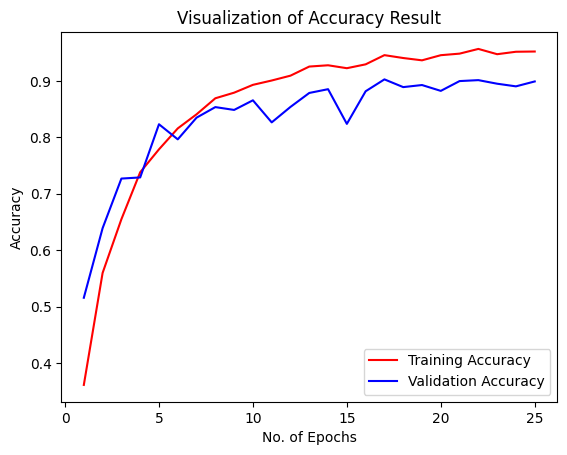

In [ ]:
#Visualization of Accuracy
epochs = [i for i in range(1, len(training_history_data['accuracy']) + 1)]
plt.plot(epochs,training_history_data['accuracy'],label="Training Accuracy",color='red')
plt.plot(epochs,training_history_data['val_accuracy'],label="Validation Accuracy",color='blue')
plt.xlabel("No. of Epochs")
plt.ylabel("Accuracy")
plt.title("Visualization of Accuracy Result")
plt.legend()
plt.show()

## Precision,Recall,Confusion Matrix - Model Evaluation-II

In [ ]:
X_test.shape

(2995, 150, 150, 1)

In [ ]:
y_pred = model.predict(X_test)
y_pred

94/94 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step


array([[2.5918553e-04, 3.2846682e-04, 1.6010022e-02, ..., 6.6608489e-01,
        7.7975687e-04, 2.9774129e-01],
       [2.9924049e-10, 6.0046159e-25, 4.4125785e-14, ..., 4.9685200e-16,
        3.1029046e-16, 1.8583341e-07],
       [4.9646733e-06, 1.8826374e-13, 1.0549351e-06, ..., 4.5536290e-06,
        1.2938048e-10, 1.0481976e-01],
       ...,
       [9.9998748e-01, 2.9250791e-22, 5.4925005e-07, ..., 5.6034999e-15,
        1.4479505e-10, 1.1970695e-05],
       [2.9210052e-03, 7.9613239e-01, 7.1126153e-03, ..., 1.4220734e-02,
        3.9667878e-02, 2.4664793e-02],
       [8.3869651e-07, 6.7860859e-09, 6.2923424e-04, ..., 3.1570781e-02,
        2.2393022e-02, 4.1653574e-03]], dtype=float32)

In [ ]:
y_pred.shape

(2995, 10)

In [ ]:
predicted_categories = np.argmax(y_pred,axis=1)
predicted_categories

array([7, 6, 6, ..., 0, 1, 3])

In [ ]:
y_test

array([[0., 0., 0., ..., 1., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [1., 0., 0., ..., 0., 0., 0.],
       [0., 1., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], dtype=float32)

In [ ]:
y_test.shape

(2995, 10)

In [ ]:
true_categories = np.argmax(y_test,axis=1)
true_categories

array([7, 6, 6, ..., 0, 1, 4])

In [ ]:
from sklearn.metrics import confusion_matrix,classification_report
cm = confusion_matrix(true_categories,predicted_categories)
# Precision Recall F1score
print(classification_report(true_categories,predicted_categories,target_names=classes))

              precision    recall  f1-score   support

       blues       0.87      0.89      0.88       302
   classical       0.94      0.95      0.95       298
     country       0.82      0.83      0.83       317
       disco       0.88      0.93      0.91       312
      hiphop       0.96      0.91      0.93       277
        jazz       0.88      0.93      0.90       311
       metal       0.97      0.96      0.96       302
         pop       0.97      0.87      0.91       289
      reggae       0.92      0.89      0.90       296
        rock       0.80      0.84      0.82       291

    accuracy                           0.90      2995
   macro avg       0.90      0.90      0.90      2995
weighted avg       0.90      0.90      0.90      2995



In [ ]:
cm

array([[270,   0,  17,   0,   0,   7,   0,   0,   2,   6],
       [  2, 283,   2,   0,   0,   9,   0,   0,   1,   1],
       [ 10,   0, 263,   5,   0,  15,   1,   1,   2,  20],
       [  1,   0,   2, 291,   3,   0,   0,   1,   2,  12],
       [  1,   1,   0,   3, 251,   2,   5,   3,   7,   4],
       [  8,   6,   5,   0,   0, 290,   0,   0,   1,   1],
       [  1,   0,   2,   2,   0,   2, 289,   0,   0,   6],
       [  2,   7,  11,   5,   1,   2,   0, 250,   6,   5],
       [  5,   0,   7,  10,   3,   2,   1,   2, 262,   4],
       [ 10,   3,  10,  13,   3,   2,   3,   1,   3, 243]])

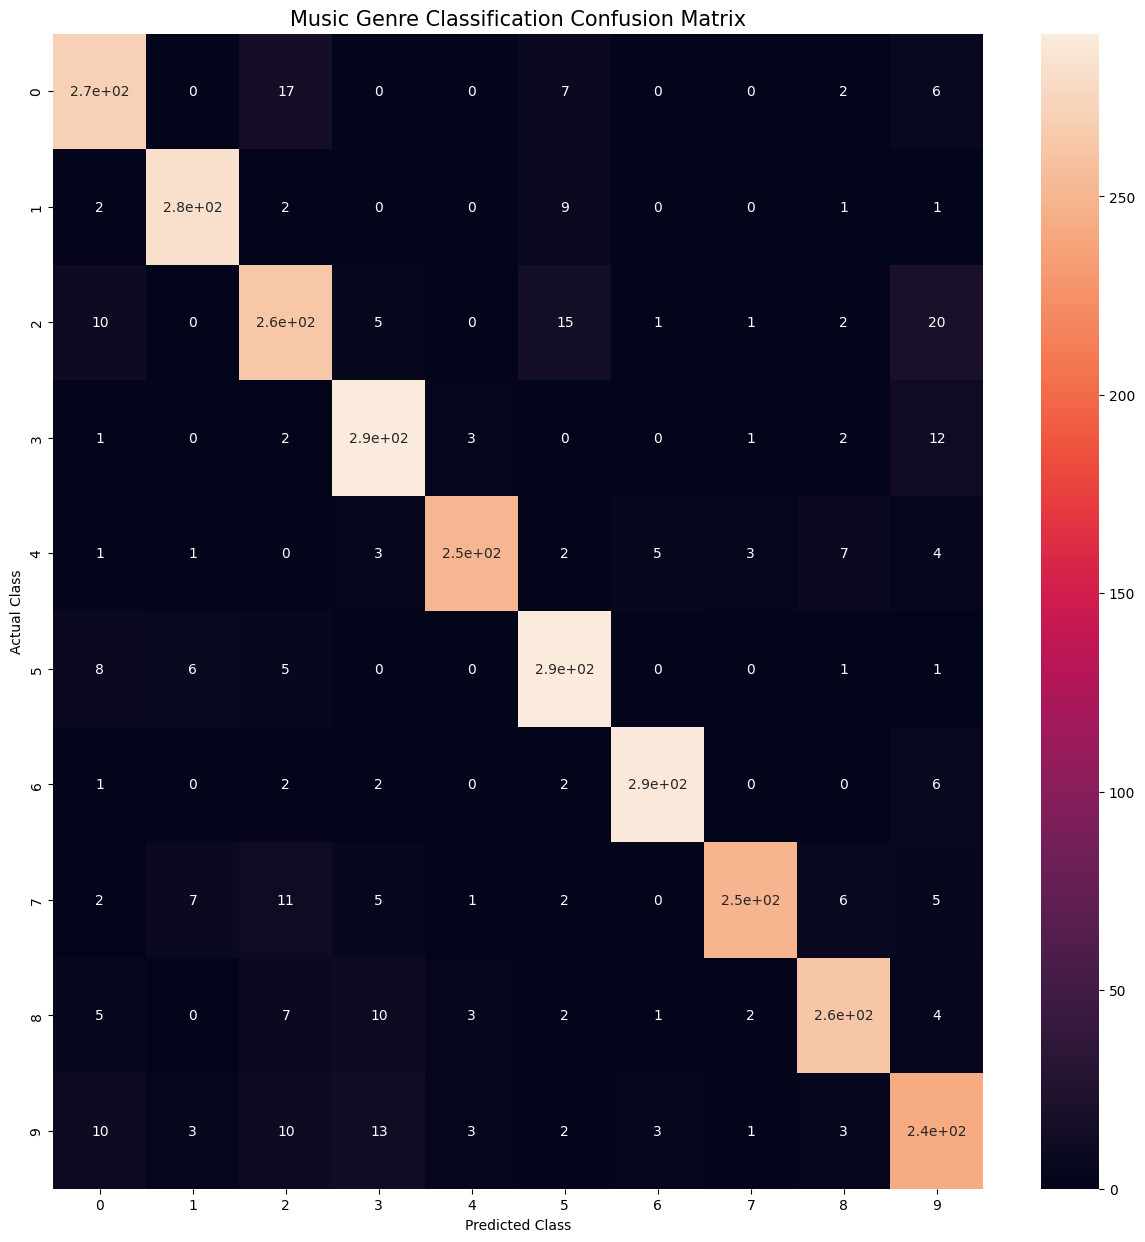

In [ ]:
import seaborn as sns
plt.figure(figsize=(15,15))
sns.heatmap(cm,annot=True,annot_kws={"size":10})
plt.xlabel("Predicted Class",fontsize=10)
plt.ylabel("Actual Class",fontsize=10)
plt.title("Music Genre Classification Confusion Matrix",fontsize=15)
plt.show()